# Tooling Atlas Index

This notebook is the map for the broad QCFD tooling atlas. It is a learning artifact, not a dependency decision.

Corpus anchors: `QRE2`, `QRE4`, `LBM14`, `CAR7`, `IO4`, `IO5`, `IO7`, `IO8`, `PRIM5`, `PRIM6`, `PRIM8`, `PRIM14`, `PRIM15`, `PRIM16`.

Source anchors: Construct, PsiQDK, Bartiq, QREF, Qualtran, qlbm, Qiskit, Azure QDK/QRE, CUDA-Q, BQSKit, PennyLane resources, Stim, PyZX, and MQT QMAP official docs/PyPI/GitHub pages.


## Vocabulary

| Term | Meaning in this project | First check |
| --- | --- | --- |
| Symbolic resources | Algebraic cost formulas over route parameters, usually before a real circuit exists. | Are formulas tied to corpus IDs and assumptions? |
| Logical resources | Logical qubits, gates, T/Toffoli counts, depth, active volume, samples. | Does the tool know actual subroutine structure? |
| Physical resources | Physical qubits, runtime, code distance, factories, QEC layout. | Which hardware/QEC assumptions were selected? |
| Circuit SDK | Tool for building or simulating concrete circuits. | Is this only a toy circuit, or tied to a QCFD operator? |
| Compiler | Tool for changing circuit gate set, topology, synthesis, routing, or equivalence. | Does the input circuit already mean something? |
| QEC estimator | Tool for decoding, sampling, or logical-to-physical overhead. | Is the QEC model explicit and comparable? |

Compact object for this notebook: a layer-by-tier matrix of candidate tools.


tooling atlas output directory: .cache\tooling_atlas


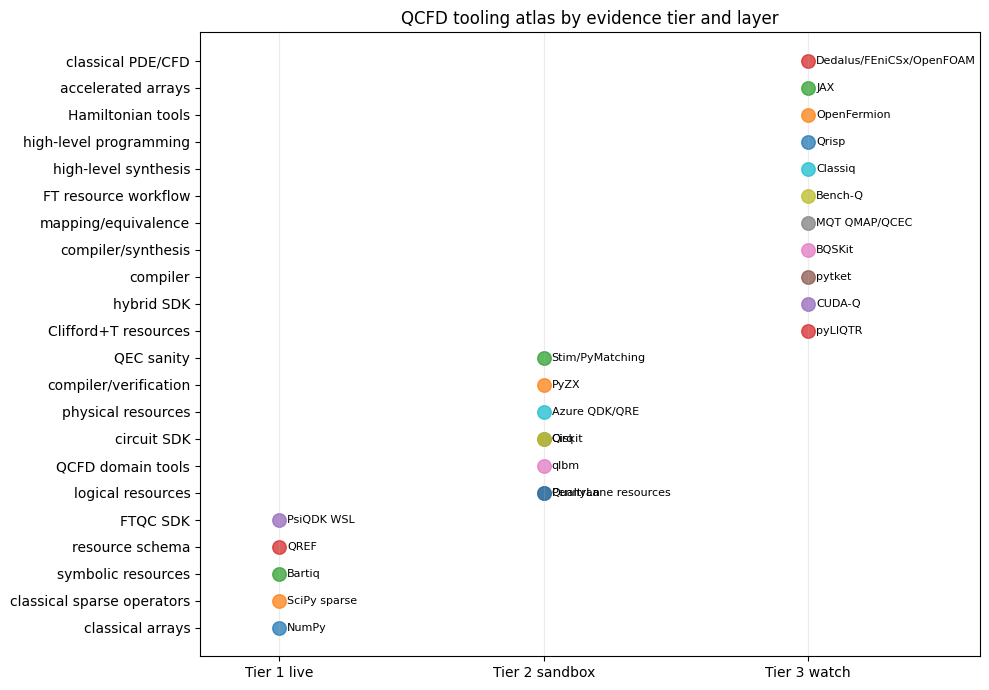

falsifiable check: 24 tool entries mapped across 22 layers


In [1]:
from pathlib import Path
import importlib.util
import json
import math

import matplotlib.pyplot as plt
import numpy as np

OUTPUT_DIR = Path('.cache/tooling_atlas')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def has_module(name: str) -> bool:
    try:
        return importlib.util.find_spec(name) is not None
    except ModuleNotFoundError:
        return False


print(f'tooling atlas output directory: {OUTPUT_DIR}')

tools = [
    {'tool': 'NumPy', 'layer': 'classical arrays', 'tier': 1, 'objective': 'baseline checks'},
    {'tool': 'SciPy sparse', 'layer': 'classical sparse operators', 'tier': 1, 'objective': 'operator validation'},
    {'tool': 'Bartiq', 'layer': 'symbolic resources', 'tier': 1, 'objective': 'route bookkeeping'},
    {'tool': 'QREF', 'layer': 'resource schema', 'tier': 1, 'objective': 'routine exchange'},
    {'tool': 'PsiQDK WSL', 'layer': 'FTQC SDK', 'tier': 1, 'objective': 'PsiQuantum primitives'},
    {'tool': 'Qualtran', 'layer': 'logical resources', 'tier': 2, 'objective': 'Bloq call graphs'},
    {'tool': 'qlbm', 'layer': 'QCFD domain tools', 'tier': 2, 'objective': 'QLBM circuit comparison'},
    {'tool': 'Qiskit', 'layer': 'circuit SDK', 'tier': 2, 'objective': 'pedagogical circuits'},
    {'tool': 'Cirq', 'layer': 'circuit SDK', 'tier': 2, 'objective': 'Google/Qualtran ecosystem'},
    {'tool': 'Azure QDK/QRE', 'layer': 'physical resources', 'tier': 2, 'objective': 'logical-to-physical estimates'},
    {'tool': 'PennyLane resources', 'layer': 'logical resources', 'tier': 2, 'objective': 'cross-check estimates'},
    {'tool': 'PyZX', 'layer': 'compiler/verification', 'tier': 2, 'objective': 'ZX optimization'},
    {'tool': 'Stim/PyMatching', 'layer': 'QEC sanity', 'tier': 2, 'objective': 'decoder intuition'},
    {'tool': 'pyLIQTR', 'layer': 'Clifford+T resources', 'tier': 3, 'objective': 'decomposition counts'},
    {'tool': 'CUDA-Q', 'layer': 'hybrid SDK', 'tier': 3, 'objective': 'CPU/GPU/QPU programming'},
    {'tool': 'pytket', 'layer': 'compiler', 'tier': 3, 'objective': 'routing/optimization'},
    {'tool': 'BQSKit', 'layer': 'compiler/synthesis', 'tier': 3, 'objective': 'gate-set synthesis'},
    {'tool': 'MQT QMAP/QCEC', 'layer': 'mapping/equivalence', 'tier': 3, 'objective': 'mapping checks'},
    {'tool': 'Bench-Q', 'layer': 'FT resource workflow', 'tier': 3, 'objective': 'architecture models'},
    {'tool': 'Classiq', 'layer': 'high-level synthesis', 'tier': 3, 'objective': 'model-level demos'},
    {'tool': 'Qrisp', 'layer': 'high-level programming', 'tier': 3, 'objective': 'programming intuition'},
    {'tool': 'OpenFermion', 'layer': 'Hamiltonian tools', 'tier': 3, 'objective': 'Pauli/Hamiltonian route watch'},
    {'tool': 'JAX', 'layer': 'accelerated arrays', 'tier': 3, 'objective': 'sweep acceleration'},
    {'tool': 'Dedalus/FEniCSx/OpenFOAM', 'layer': 'classical PDE/CFD', 'tier': 3, 'objective': 'classical comparators'},
]

layers = list(dict.fromkeys(row['layer'] for row in tools))
fig, ax = plt.subplots(figsize=(10, 7))
for row in tools:
    x = row['tier']
    y = layers.index(row['layer'])
    ax.scatter(x, y, s=95, alpha=0.75)
    ax.text(x + 0.03, y, row['tool'], va='center', fontsize=8)
ax.set_xticks([1, 2, 3], ['Tier 1 live', 'Tier 2 sandbox', 'Tier 3 watch'])
ax.set_yticks(range(len(layers)), layers)
ax.set_xlim(0.7, 3.65)
ax.grid(axis='x', alpha=0.25)
ax.set_title('QCFD tooling atlas by evidence tier and layer')
plt.tight_layout()
plt.show()

assert {row['tier'] for row in tools} == {1, 2, 3}
assert all(row['tool'] and row['layer'] and row['objective'] for row in tools)
print(f'falsifiable check: {len(tools)} tool entries mapped across {len(layers)} layers')


In [2]:
# Sandbox package inventory: generated from .cache/tooling_atlas/installed_packages_report.json.
from pathlib import Path
import json

report_path = Path('.cache/tooling_atlas/installed_packages_report.json')
if report_path.exists():
    report = json.loads(report_path.read_text(encoding='utf-8'))
    rows = []
    for env_name, env in report.items():
        for package, info in env['packages'].items():
            rows.append({
                'env': env_name,
                'package': package,
                'version': info.get('version') or '',
                'import': 'ok' if info.get('import_ok') else 'blocked',
                'note': info.get('error') or '',
            })
    try:
        import pandas as pd
        display(pd.DataFrame(rows))
    except Exception:
        for row in rows:
            print(f"{row['env']:12s} {row['package']:16s} {row['version']:10s} {row['import']:8s} {row['note']}")
else:
    print('No sandbox report found yet. Run the package audit to create .cache/tooling_atlas/installed_packages_report.json.')

No sandbox report found yet. Run the package audit to create .cache/tooling_atlas/installed_packages_report.json.


## What This Cannot Prove

This atlas proves only that we have a structured comparison surface. It does not prove that any tool produces a valid QCFD route, that any loading/readout assumption is acceptable, or that any resource estimate is paper-grounded.
